ClassifyThermalMetadata: thermal_range='None' temperature=None inference_type='none' thermal_reasoning="The metadata provides the country of origin ('China: Donghu Lake, Wuhan') but does not specify a temperature or thermal condition (psychrophile, mesophile, or thermophile) associated with the bacteriophage or its host." thermal_confidence=None thermal_found=False


download: s3://pmc-oa-opendata/PMC13048485.1/PMC13048485.1.txt to data/accessions/ADI87650/library/accession_lit/PMC13048485.1.txt
download: s3://pmc-oa-opendata/PMC13030558.1/PMC13030558.1.txt to data/accessions/ADI87650/library/accession_lit/PMC13030558.1.txt
download: s3://pmc-oa-opendata/PMC13055312.1/PMC13055312.1.txt to data/accessions/ADI87650/library/accession_lit/PMC13055312.1.txt
download: s3://pmc-oa-opendata/PMC12929629.1/PMC12929629.1.txt to data/accessions/ADI87650/library/accession_lit/PMC12929629.1.txt
download: s3://pmc-oa-opendata/PMC12919812.1/PMC12919812.1.txt to data/accessions/ADI87650/library/accessi

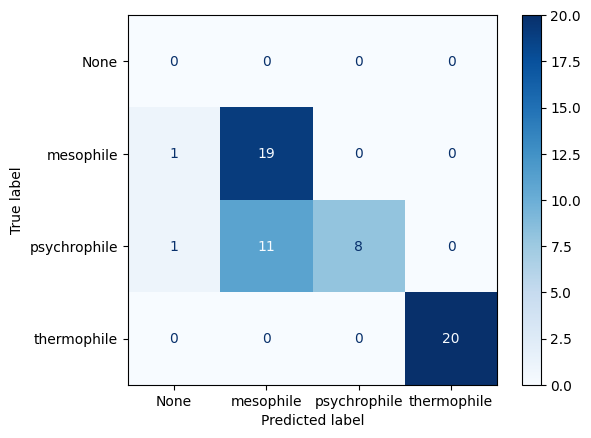

Total Duration: 51.95 minutes


/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [2]:
############################################################################################################################################################
# GEMMA4
############################################################################################################################################################
from sklearn.metrics import classification_report
from agents import *
import pandas as pd
import json
from tools import *
import matplotlib.pyplot as plt

# State rows to keep
keep=['accession', 'thermal_range', 'thermal_source', 'thermal_reasoning', 'thermal_confidence', 'thermal_source', 'inference_type', 'thermal_paper', 'host','taxonomic_level','host_reasoning','host_confidence','host_source','host_paper','duration', 'nodes', 'timings']

#Getting accessions
ex_df=pd.read_csv('data/example/expanded_example_data.csv')
accessions=ex_df['Accession']


all_df = pd.DataFrame()

# Classifying each accession
for acc in accessions:
    result = MESOTHERMOPSYCHRO(acc, "gemma4:e4b")
    print(f'Accession: {acc}\nThermal Range: {result["thermal_range"]}\n\n')
    df = pd.DataFrame([result])

    # serialize complex fields
    df["metadata"] = df["metadata"].apply(json.dumps)
    df["timings"] = df["timings"].apply(json.dumps)
    df["nodes"] = df["nodes"].apply(json.dumps)

    all_df = pd.concat([all_df, df], ignore_index=True)

all_df.to_csv('results/result.csv', index=False)

# Create confusion matrix
actual=ex_df['Thermal Range']
pred=all_df['thermal_range']

#Clean out None
actual_clean = actual.fillna("unknown")
pred_clean = pred.fillna("unknown")

plot=ConfusionMatrix(actual_clean, pred_clean)
plot.plot(cmap='Blues')
plt.savefig('results/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# Total duration
import pandas as pd
df=pd.read_csv('results/result.csv')
total_duration=0
for i in df['duration']:
    total_duration+=i
print(f'Total Duration: {round((total_duration/60),2)} minutes')

# Get the classification report
classification_report=classification_report(actual_clean, pred_clean)

with open('results/classification_report.txt', 'w') as f:
    f.write(classification_report)
    f.write(f'\n\n Total Duration: {round((total_duration/60),2)} minutes')
